<a href="https://colab.research.google.com/github/uniquegalaxycoder/Project/blob/main/Bike%20Sharing%20Case%20Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Bike Sharing Case Study**

---



## **Problem Statement**

### **Context:**

Bike-sharing systems are a new generation of traditional bike rentals where the whole process from membership, rental and return has become automatic. Through these systems, the user can easily rent a bike from a particular position and return to another position. Currently, there are about over 500 bike-sharing programs around the world which are composed of over 500 thousand bicycles. Today, there exists a great interest in these systems due to their important role in traffic, environmental, and health issues.

### **Objective:**

'Travel Along' is a new bike-sharing company and wants to expand its customer count and provide better services at a reasonable cost. They have conducted several surveys and collated the data about weather, weekends, holidays, etc. from the past 2 years.

As a recently hired data scientist at 'Travel Along', you have been asked to analyze the patterns in the data and figure out the key areas which can help the organization to grow and manage the customer demands. Further, you need to use this information to predict the count of bikes shared so that the company can take prior decisions for surge hours.

  * What are the different factors which affect the target variable? What business recommendations can we give based on the analysis?
  * How can we use different ensemble techniques - Bagging, Boosting, and Stacking to build a model to predict the count of bikes rented?

### **Data Description:**

* The bike-sharing rental process is highly correlated to the environmental and seasonal settings. For instance, weather conditions, precipitation, the day of week, season, the hour of the day, etc. can affect the rental behaviors.

* **instant:** record index
* **dteday :** date
* **season :** season (1:spring, 2:summer, 3:fall, 4:winter)
* **yr :** year (0: 2011, 1:2012)
* **mnth :** month ( 1 to 12)
* **hr :** hour (0 to 23)
* **holiday :** whether the day is holiday or not
* **weekday :** day of the week
* **workingday :** if day is neither weekend nor holiday then 1, otherwise is 0.
* **weathersit :**
    * 1: Clear, Few clouds, Partly cloudy
    * 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
    * 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
    * 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
* **temp :** Normalized temperature in Celsius. The values are divided by 41 (max)
* **atemp:** Normalized feeling temperature in Celsius. The values are divided to 50 (max). The “feel like” temperature relies on environmental data including the ambient air temperature, relative humidity, and wind speed to determine how weather conditions feel to bare skin.
* **hum:** Normalized humidity. The values are divided by 100 (max)
* **windspeed:** Normalized wind speed. The values are divided by 67 (max)
* **casual:** count of casual users
* **registered:** count of registered users
* **cnt:** count of total rental bikes including both casual and registered

In [ ]:
# importing libraries
import pandas as pd
import numpy as np
import math

# importing libraries for visualization
import seaborn as sns
import matplotlib.pyplot as plt

# to maintain the number precision
pd.options.display.float_format = '{:.5f}'.format

# to ignore warnings
import warnings
warnings.filterwarnings('ignore')

# imprting a model for splitting the data into trian & test
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, StackingRegressor
from xgboost import XGBRegressor
from sklearn import metrics
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split

In [ ]:
# importing some sciket learn function
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error, r2_score

In [ ]:
# connecting google drive to colab
from google.colab import drive
drive.mount('/content/drive', force_remount= True)

Mounted at /content/drive


In [ ]:
# loading the data
try :
  data = pd.read_csv('/content/drive/My Drive/Python 2026/practice csv files/hour.csv')
  print(" 🚀 Data loaded successfuly")
except Exception as a :
  print(f"Loading error!, {a}")

 🚀 Data loaded successfuly


In [ ]:
# making copy of original data
df = data.copy()

In [ ]:
# checking the table shape
rows, column = df.shape
print(f"Total Rows : {rows} \nTotal Columns {column}")

Total Rows : 17379 
Total Columns 17


In [ ]:
# checking the table information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


* There are total 17 columns with 17379 rows.

* There is no null value is present, there are 16 columns are numerical & 1 categorical column

In [ ]:
# checking the duplicates in table
df.duplicated().sum()

np.int64(0)

* There is no duplicate rows/data

In [ ]:
# checking the null value in table
df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


* There is no null value is present in table

In [ ]:
# checking the table overview
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24000,0.28790,0.81000,0.00000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22000,0.27270,0.80000,0.00000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22000,0.27270,0.80000,0.00000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24000,0.28790,0.75000,0.00000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24000,0.28790,0.75000,0.00000,0,1,1


Here in above table dteday column is a categorical column so, we need to convert this into datetime datatype.

In [ ]:
# droping some unwanted columns from table
# here **instant** columns is not required, it is only unique identifier for each record.
df.drop(['instant', 'dteday'], inplace = True, axis = 1)

In [ ]:
# checking the some statistical information from all attributes
df.describe().T

,count,mean,std,min,25%,50%,75%,max
season,17379.00000,2.50164,1.10692,1.00000,2.00000,3.00000,3.00000,4.00000
yr,17379.00000,0.50256,0.50001,0.00000,0.00000,1.00000,1.00000,1.00000
mnth,17379.00000,6.53778,3.43878,1.00000,4.00000,7.00000,10.00000,12.00000
hr,17379.00000,11.54675,6.91441,0.00000,6.00000,12.00000,18.00000,23.00000
holiday,17379.00000,0.02877,0.16717,0.00000,0.00000,0.00000,0.00000,1.00000
weekday,17379.00000,3.00368,2.00577,0.00000,1.00000,3.00000,5.00000,6.00000
workingday,17379.00000,0.68272,0.46543,0.00000,0.00000,1.00000,1.00000,1.00000
weathersit,17379.00000,1.42528,0.63936,1.00000,1.00000,1.00000,2.00000,4.00000
temp,17379.00000,0.49699,0.19256,0.02000,0.34000,0.50000,0.66000,1.00000
atemp,17379.00000,0.47578,0.17185,0.00000,0.33330,0.48480,0.62120,1.00000


* On an average *Clear, Few clouds, Partly cloudy* weather in table records.
* On an average Bike sharing demand on 11 hr in a day.
* 75% of the time demand is there for bike-sharing.
* mean temp approx .49 degree celsius & median temp. approx 0.50
* mean atemp approx 0.47 & approx 0.48 median atemp.  
* On an average windspeed is approx 0.19 but there is a extream value on right side.
* as per the above, we can see our target column (cnt) has highly right side skewed.

In [ ]:
# checking the data quntom around the each categorical data.

cat_column = ['season','yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']

for i in cat_column :
  a = df[i].value_counts()
  print(a)
  print("*"* 40)

season
3    4496
2    4409
1    4242
4    4232
Name: count, dtype: int64
****************************************
yr
1    8734
0    8645
Name: count, dtype: int64
****************************************
mnth
7     1488
5     1488
12    1483
8     1475
3     1473
10    1451
6     1440
4     1437
9     1437
11    1437
1     1429
2     1341
Name: count, dtype: int64
****************************************
hr
16    730
17    730
15    729
14    729
13    729
12    728
18    728
19    728
20    728
21    728
22    728
23    728
8     727
9     727
10    727
7     727
11    727
0     726
6     725
1     724
5     717
2     715
4     697
3     697
Name: count, dtype: int64
****************************************
holiday
0    16879
1      500
Name: count, dtype: int64
****************************************
weekday
6    2512
0    2502
5    2487
1    2479
3    2475
4    2471
2    2453
Name: count, dtype: int64
****************************************
workingday
1    11865
0     5514
Name: c

* There is slightly more records on 0 which is 2011 yr than 1 i.e 2012 yr.
* There is more demand on non-holiday days.
* There is more demand on working day's.
* Demand for bike-sharing is significantly higher in favorable weather conditions (clear, few clouds, partly cloudy), whereas it drops to near to zero during extreme weather conditions like heavy rain, thunderstorms, snow, or fog.

# **EDA**

In [ ]:
# Univariate analysis

def histplot_boxplot(df, features:list):

  """
  Plot Histogram and Boxplot for given features.

    Parameters:
    df : pandas.DataFrame
        Input dataset
    features : list
        List of numerical column names

    Returns:
    None
  """

  n_column = 3
  n_rows = math.ceil(len(features)/n_column)
  # Defining the plot size of histogram
  plt.figure(figsize = (18, 3*n_rows))
  # plotting the histplot using features & data
  for j, feature in enumerate(features) :
    plt.subplot(n_rows, n_column, j + 1)
    sns.histplot(data = df, x = feature, kde = True, color = 'skyblue')

    plt.title(f"Histogram of {feature}")
  plt.tight_layout
  plt.show()

    # ploting boxplot using features list & data
  plt.figure(figsize = (25, 3* n_rows))
  for k, feature in enumerate(features) :
    plt.subplot(n_rows, n_column, k + 1)
    sns.boxplot(data = df, x = feature, color = 'lightgreen')

    plt.title(f"Boxplot of {feature}")

  plt.tight_layout
  plt.show()

In [ ]:
def count_plot(data, x):
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Summary table
    summary = (
        data.groupby(x)
        .size()
        .div(len(data))
        .reset_index(name='Percentage')
    )

    # Figure size based on categories
    n = data[x].nunique()
    plt.figure(figsize=(n * 3, 4))

    # Plot
    plot = sns.countplot(data=data, x=x, palette="viridis")

    # Add labels on bars
    for container in plot.containers:
        plot.bar_label(container)

    plt.title(f"{x} Distribution")
    plt.xlabel(x)
    plt.ylabel("Count")
    plt.xticks(rotation=45)

    plt.show()

    return summary

In [ ]:
# bi-variate Analysis

def bargraph_plot(data, x, hue):

  summary = data.groupby([x, hue]).size().div(data.shape[0]).reset_index(name = 'Percentage')

  n = data[x].nunique()  # total unique values
  plt.figure(figsize = (n*3.5, 4))   # figure size
  bar_width = min(0.8, max(0.8, 2/n))  # set bar width
  plt.title(f"{x} Vs. {hue}") # title
  plot = sns.countplot(data=data, x = x, hue = hue, palette= "viridis" , width = bar_width)  # plotting graph
  # plt.ylim(0,  data[hue].value_counts().max()) # set bar hight
  for value in plot.containers :   # plotting values on bar
    plot.bar_label(value)
  return summary
  plt.show()

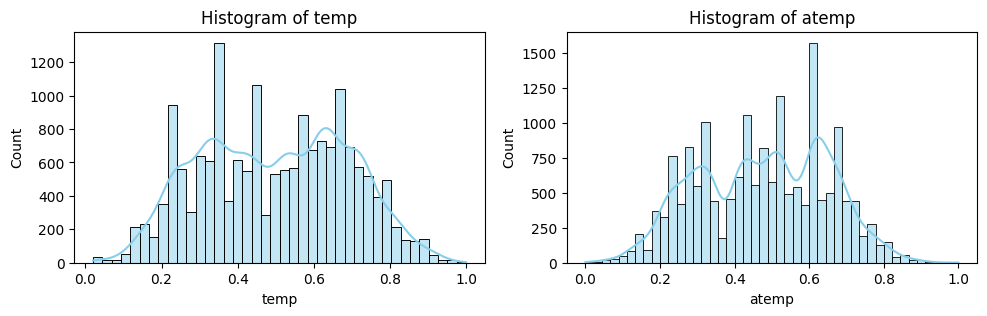

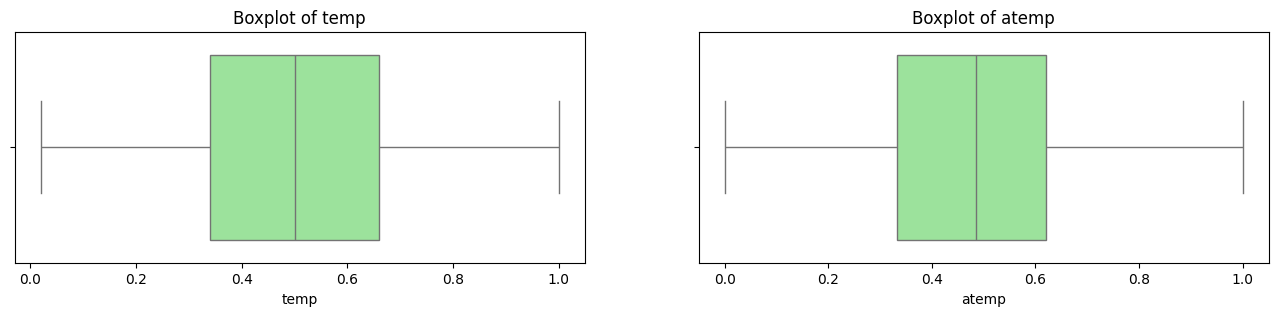

In [ ]:
histplot_boxplot(df, ['temp', 'atemp'])

* The temperature distribution is approximately normal. Around 25% of the observations have temperature values below 0.37, while 75% are below 0.65. The average recorded temperature is approximately 0.50.

* around the same temperature is observed on atemp columns. On an average 0.50 tempature (atemp).

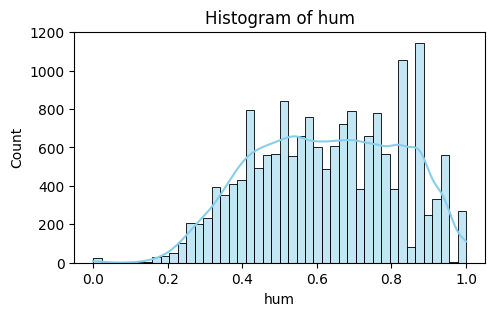

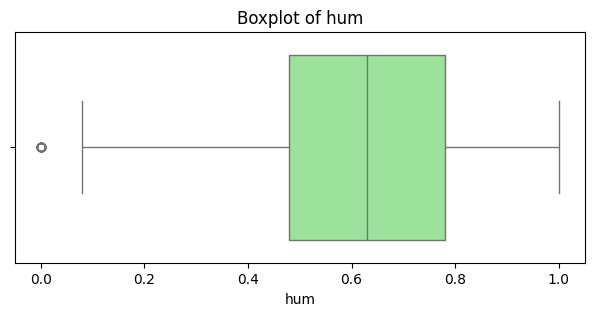

In [ ]:
histplot_boxplot(df, ['hum'])

* humidity is highly left side skewed.
* 75% of the records indicating the humidity is less than 0.79 & mean humidity is <= 0.62.

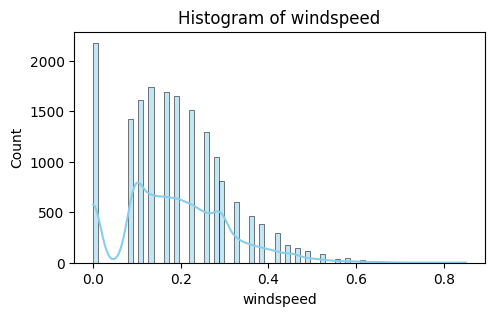

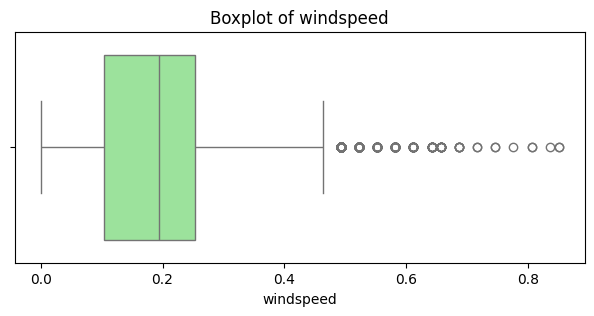

In [ ]:
histplot_boxplot(df, ['windspeed'])

* windspeed observation are highly right side skewed.
* also outliers are present in data.
* On an average windspeed value is around 0.19.
* most of the records observed at 0 windspeed.

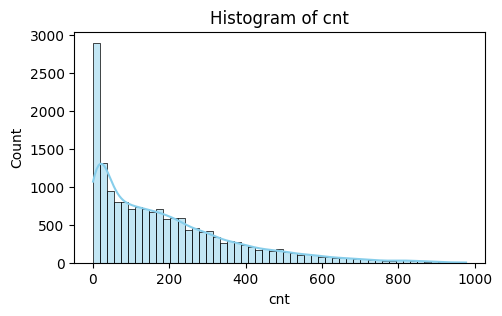

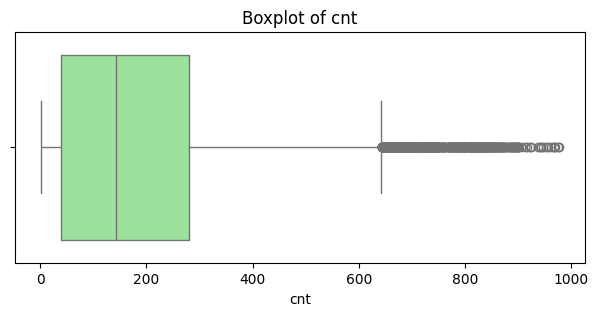

In [ ]:
histplot_boxplot(df, ['cnt'])

* In cnt columns (Target column) highly outliers are present.
* Indicating target column is highly right side skewed.
* On an average bike demand is around ~180.
* also it is indicating some time demand is almost 0 or near to 0.

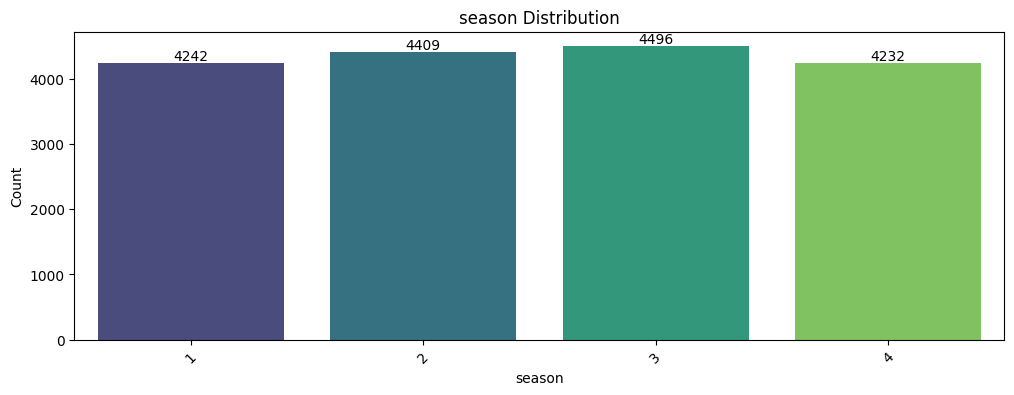

,season,Percentage
0,1,0.24409
1,2,0.25370
2,3,0.25870
3,4,0.24351


In [ ]:
count_plot(df, 'season')

* at season 2 & 3 *i.e [2:summer, 3:fall]*  has more observation

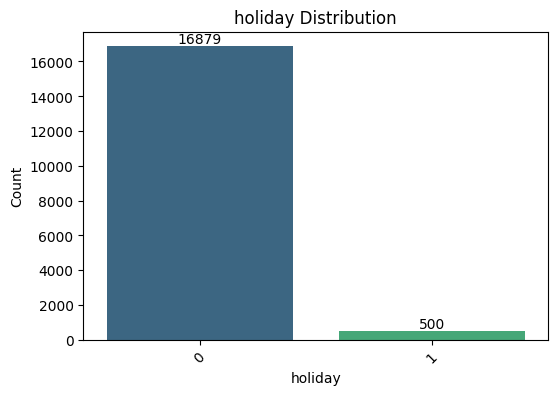

,holiday,Percentage
0,0,0.97123
1,1,0.02877


In [ ]:
count_plot(df, 'holiday')

As expected more no. of observation on non-holidays.

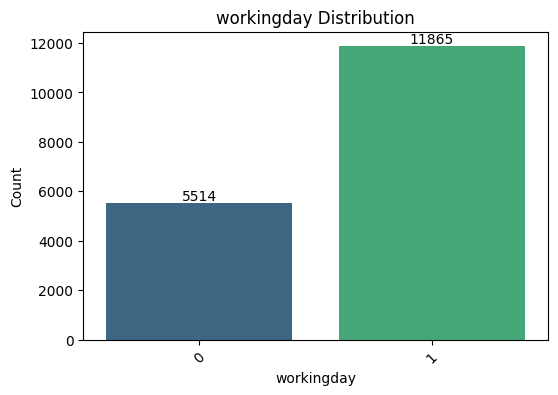

,workingday,Percentage
0,0,0.31728
1,1,0.68272


In [ ]:
count_plot(df, 'workingday')

More observation are recorded on working days as expected as compaire to Non- Working day's.

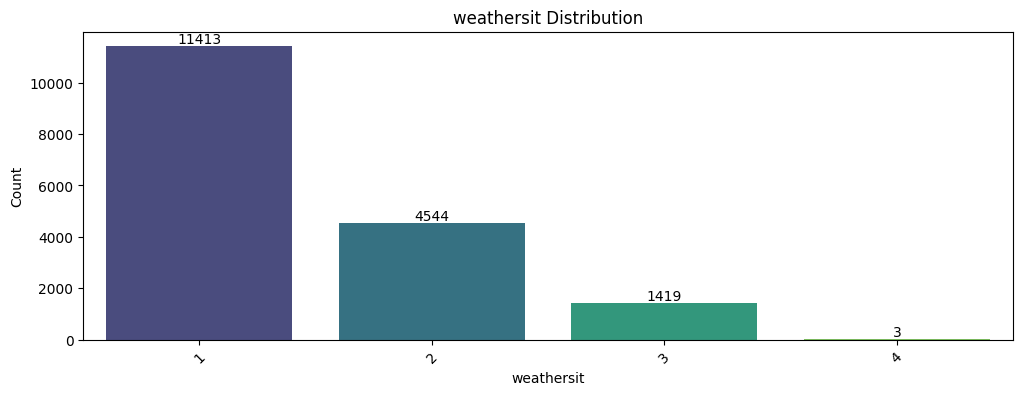

,weathersit,Percentage
0,1,0.65671
1,2,0.26146
2,3,0.08165
3,4,0.00017


In [ ]:
count_plot(df, 'weathersit')

More no. of observation recorded on 1 i.e. *[Clear, Few clouds, Partly cloudy]* weather.

##### **Checking the correlation between the numerical features.**

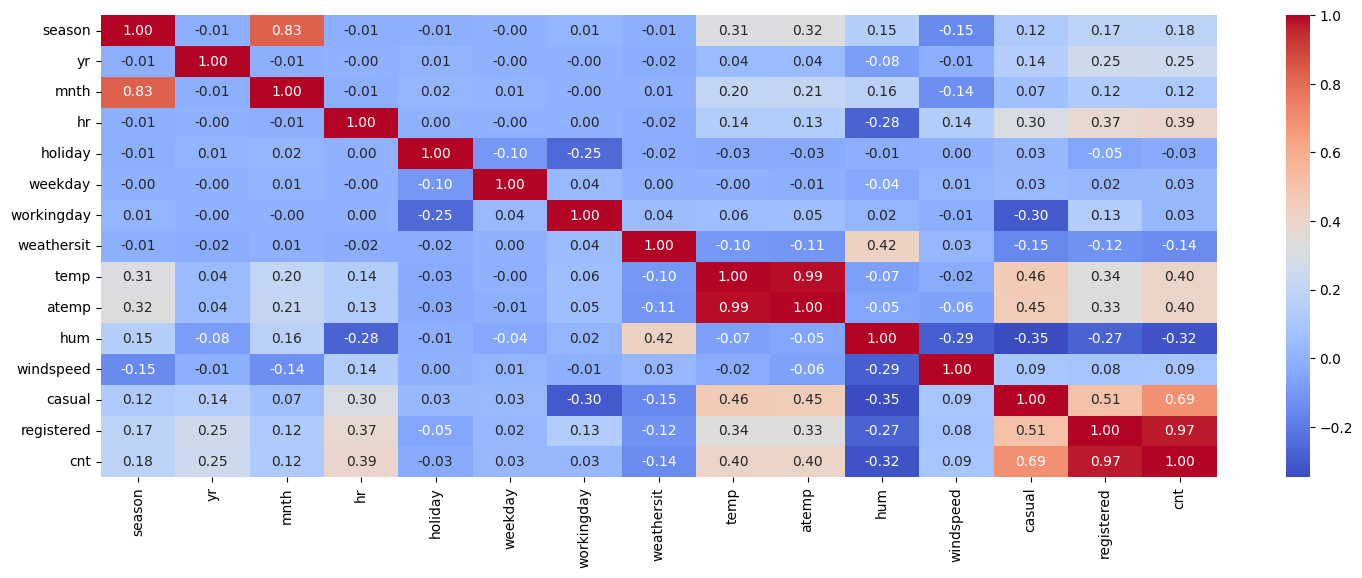

In [ ]:
plt.figure(figsize = (18, 6))
sns.heatmap(data = df.select_dtypes(include= ['number']).corr(), annot = True, fmt = '0.2f', cmap = 'coolwarm')
plt.show()

* Season & month column both have high correlation, followed by temperature & Feels like temperature with season.
* hr & cnt has moderate correlation ~0.39 & nigative correlation with ~(-0.28).
* Workingday & casual user bike demand is negative correlation ~(-0.30).
* weathersit & humidity has good correlation ~0.42.
* all users(cnt) & Temperature , fees like temprature has good correlation. ~0.40.
* registered users & cnt having high correlation between them almost ~0.97.  

In [ ]:
sns.set(rc = {'figure.figsize': (21, 7)})
sns.catplot(x = 'season', y = 'cnt', kind = 'swarm', data = df, height= 7, aspect= 3)

* in season 1 there are less demand for rental bikes as compaire to others.
* The highest number of bikes are shared in 3rd season.


In [ ]:
sns.set(rc = {'figure.figsize': (21, 7)})
sns.catplot(x = 'holiday', y = 'cnt', kind = 'swarm', data = df, height= 7, aspect= 3)

On holiday there is no any high demand for bike sharing.

In [ ]:
sns.set(rc = {'figure.figsize': (21, 7)})
sns.catplot(x = 'weekday', y = 'cnt', kind = 'swarm', data = df, height= 7, aspect= 3)

In [ ]:
sns.set(rc = {'figure.figsize': (21, 7)})
sns.catplot(x = 'hr', y = 'cnt', kind = 'swarm', data = df, height= 7, aspect= 3)

In [ ]:
sns.set(rc = {'figure.figsize': (21, 7)})
sns.catplot(x = 'mnth', y = 'cnt', kind = 'swarm', data = df, height= 7, aspect= 3)

In [ ]:
sns.set(rc = {'figure.figsize': (12, 5)})
pd.pivot_table(data = df, index = ['yr', 'season'], values = 'cnt', aggfunc= np.sum).plot(kind = 'bar');

In year & season wise, no. of observation are increraseing year on year. most important is the pattern of season are same.
for eg. in year 2011 season 1st is lower demand same if we observing on year 2012 season 1st demand is low. season 3rd in both the year demand is high.

## **Data Pre-Processing**

**Outlier Detection and Treatment**

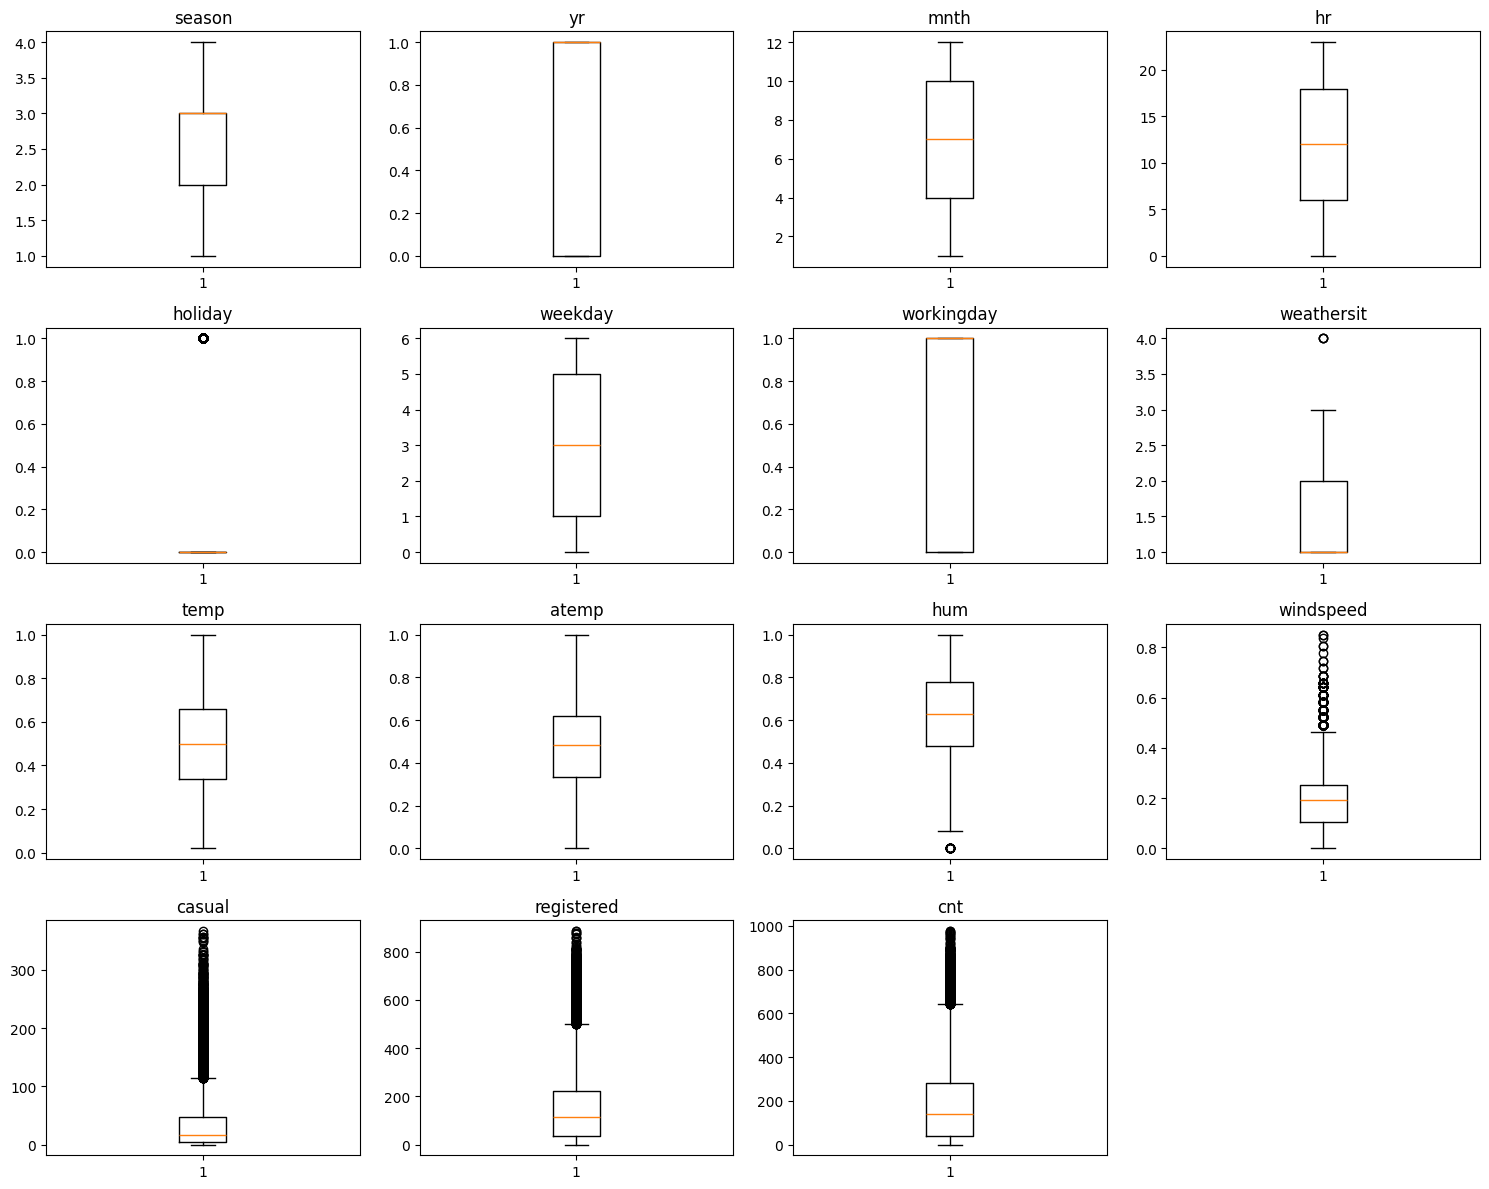

In [ ]:
numeric_columns = df.select_dtypes(include = np.number).columns.tolist()

plt.figure(figsize = (15,12))
for i, variables in enumerate(numeric_columns):
  plt.subplot(4, 4, i+1)
  plt.boxplot(df[variables], whis = 1.5)
  plt.tight_layout()
  plt.title(variables)

plt.show()

* Few attributes are containing the outliers in the data.
* However we are not considering them as they are proper values.

For data Preprocessing, in table casual & registered columns are not usefull for further process because we haveone column which is the addition of this columns.

In [ ]:
# dropping the unwanted columns
df.drop(['casual', 'registered'], inplace = True, axis= 1)

##### **Data Prepration for model building**

In [ ]:
# splitting the data into two varibale, X & y [train & test]
X = df.drop('cnt', axis = 1)
y = df['cnt']

In [ ]:
# passing the data for train & test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.3,
    random_state = 1,
    shuffle= True
)

In [ ]:
X_train.shape, X_test.shape

((12165, 12), (5214, 12))

# **Building Bagging Model's**

In [ ]:
#Defining the adjusted R_score function

def adj_r2_score(prdictors, target, prediction):
  r2 = r2_score(target, prediction)
  n = prdictors.shape[0]
  k = prdictors.shape[1]
  return 1- (( 1 - r2 ) * ( n-1 ) / ( n- k - 1))


# function to compute MAPE

def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100

In [ ]:
def Model_performance_regression(model, prdictors, target) :
    """
    Model to compute different metrics to check regression model performance

    model = Regression Model
    predictors = Independent variable
    target = dependent variable
    """

    pred = model.predict(prdictors)

    mape = mape_score(target, pred)
    mae = mean_absolute_error(target, pred)
    mse = mean_squared_error(target, pred)
    rmse = np.sqrt(mean_squared_error(target, pred))
    r2 = r2_score(target, pred)
    adj_r2 = adj_r2_score(prdictors,target, pred)

    summary = pd.DataFrame({
        "MAPE" :  mape,
        "MAE" : mae,
        "MSE" : mse,
        "RMSE" : rmse,
        "R2 Score" : r2,
        "adj_r2" : adj_r2
    }, index = [0])

    return summary

### **Decision Tree Regressor (simple)**

In [ ]:
# defining the model
simple_dtree_regressor = DecisionTreeRegressor(random_state = 1)

In [ ]:
# fitting train data into trained model
simple_dtree_regressor.fit(X_train, y_train)

DecisionTreeRegressor(random_state=1)

In [ ]:
# checking model performance on train data
simple_dt_model_evaluation_train = Model_performance_regression(simple_dtree_regressor, X_train, y_train)
simple_dt_model_evaluation_train

,MAPE,MAE,MSE,RMSE,R2 Score,adj_r2
0,0.00426,0.00575,0.19573,0.44241,0.99999,0.99999


In [ ]:
# checking the model performance on Test data (Unseen data)
simple_dt_model_evaluation_test = Model_performance_regression(simple_dtree_regressor, X_test, y_test)
simple_dt_model_evaluation_test

,MAPE,MAE,MSE,RMSE,R2 Score,adj_r2
0,38.03325,35.10779,3700.02532,60.82783,0.89223,0.89198


* On train data our model performing well, but on test data it getting overfitting.
* On train data R2 score is near to 1, but in test data it get dropped by 11%.
* On train data MAPE is around 0.4% error rate, but on test data it goes on 38%.
* Model is not genralizing well on unseen data.

### **Decision Tree Regressor (Tunned)**

In [ ]:
# defining the parameter grid for grid search cv
param_grid = {
    'max_depth' : list(np.arange(2, 20))+[None],
    'min_samples_leaf': [1, 3, 5, 7, 10],
    'max_leaf_nodes' : [2, 3, 5, 10, 15] + [None],
    'min_impurity_decrease' : [0.001, 0.01, 0.1, 0.0]
}

# Type of scoring used to compare parameter combinations
score = metrics.make_scorer(metrics.r2_score)

# GridSearchCV
grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=1),
    param_grid = param_grid,
    scoring= score,
    cv = 5
)

# fitting the data
grid_search.fit(X_train, y_train)

# best estimatoers
tunned_dtree_regressor = grid_search.best_estimator_

In [ ]:
# fitting the data into best estimatoer
tunned_dtree_regressor.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=np.int64(14), min_impurity_decrease=0.1,
                      min_samples_leaf=5, random_state=1)

In [ ]:
# checking the model performance on train data
tunned_dt_model_evaluation_train = Model_performance_regression(tunned_dtree_regressor, X_train, y_train)
tunned_dt_model_evaluation_train

,MAPE,MAE,MSE,RMSE,R2 Score,adj_r2
0,28.65731,22.52534,1328.07711,36.44279,0.95886,0.95882


In [ ]:
# model performance on test data
tunned_dt_model_evaluation_test = Model_performance_regression(tunned_dtree_regressor, X_test, y_test)
tunned_dt_model_evaluation_test

,MAPE,MAE,MSE,RMSE,R2 Score,adj_r2
0,38.35640,31.84136,3021.69622,54.96996,0.91199,0.91178


* Model well perform on train data as well on test data, after tunning model it will well genralized on unseen data.
* Test score is increased by 2%. Also, RMSE is reduced by 6%.
* Overfitting is reduced, model genralized well on unseen data.

### **Feature importance**

In [ ]:
# feature importance
feature_importance = pd.DataFrame({
    "Features" : X_train.columns,
    "Importance" : tunned_dtree_regressor.feature_importances_.round(2)
}).sort_values(by = ['Importance'], ascending = False).reset_index(drop=True)

print(feature_importance)


      Features  Importance
0           hr     0.63000
1         temp     0.12000
2           yr     0.08000
3   workingday     0.06000
4          hum     0.02000
5       season     0.02000
6        atemp     0.02000
7   weathersit     0.02000
8         mnth     0.01000
9      weekday     0.01000
10     holiday     0.00000
11   windspeed     0.00000


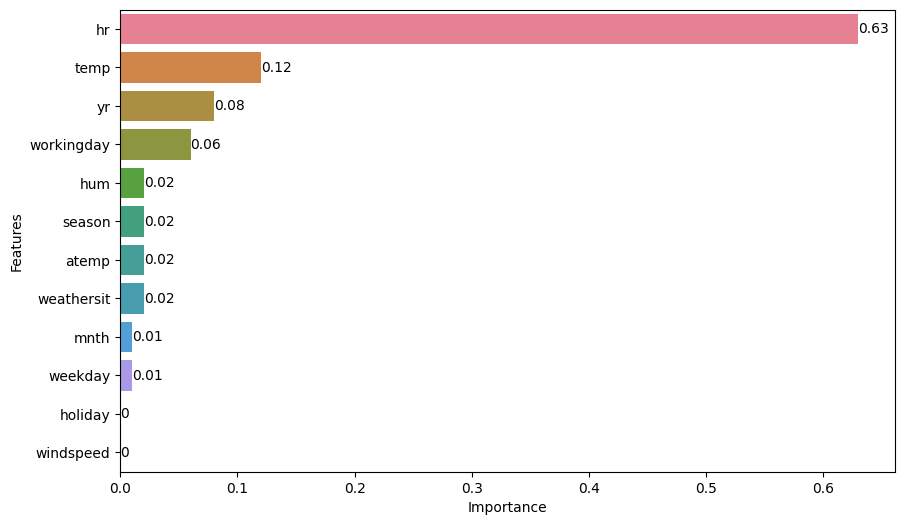

In [ ]:
# plotting above table into graph

plt.figure(figsize = (10, 6))
plot_1 = sns.barplot(feature_importance, x = 'Importance', y = 'Features', hue = 'Features')

for value in plot_1.containers :
  plot_1.bar_label(value)

plt.show()

##### **As per Tunned Decision Tree Regressor model Hr, Temperature, year, workingday parameters are impacting the bike rental demand.**

### **Random Forest (simple)**

In [ ]:
# defining simple model
simple_random_forest = RandomForestRegressor(random_state=1)

In [ ]:
# passing the train data into trained model
simple_random_forest.fit(X_train, y_train)

RandomForestRegressor(random_state=1)

In [ ]:
# checking the model performance on trained data
simple_randomF_model_evaluation_train = Model_performance_regression(simple_random_forest, X_train, y_train)
simple_randomF_model_evaluation_train

,MAPE,MAE,MSE,RMSE,R2 Score,adj_r2
0,11.75733,9.64132,261.38550,16.16742,0.99190,0.99189


In [ ]:
# checking the model performance on test data
simple_randomF_model_evaluation_test = Model_performance_regression(simple_random_forest, X_test, y_test)
simple_randomF_model_evaluation_test

,MAPE,MAE,MSE,RMSE,R2 Score,adj_r2
0,32.74863,26.19237,1985.78521,44.56215,0.94216,0.94203


* On simple random forest regressor our model performing well on train data.
* On unseen data model getting slightly overfitted & R2 score on test data is around 0.94.
* let's overcome this overfitting by hyperparameter tunning.

### **Random Forest (Tunned)**

In [ ]:
# defining the hyperparameter values for GridSearchCV
param_grid = {
    'max_depth' : [np.arange(4, 10, 2)]+[None],
    'max_features' : ['sqrt', 'log2', None],
    'n_estimators' : np.arange(80, 120, 10)
}

In [ ]:
# defining the matrics
scoring = metrics.make_scorer(metrics.r2_score)

# defining the GridSearchCV with passing the parameters on it
tunned_grid = GridSearchCV(
    estimator= RandomForestRegressor(random_state=1),
    param_grid = param_grid,
    cv = 5,
    scoring = scoring
)

In [ ]:
# passing the train data into model
tunned_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=1),
             param_grid={'max_depth': [array([4, 6, 8]), None],
                         'max_features': ['sqrt', 'log2', None],
                         'n_estimators': array([ 80,  90, 100, 110])},
             scoring=make_scorer(r2_score, response_method='predict'))

In [ ]:
# checking the best parameters
best_parameter = tunned_grid.best_params_
best_parameter

{'max_depth': None, 'max_features': None, 'n_estimators': np.int64(110)}

In [ ]:
# best estimators
tunned_random_forest = tunned_grid.best_estimator_
tunned_random_forest

RandomForestRegressor(max_features=None, n_estimators=np.int64(110),
                      random_state=1)

In [ ]:
# fitting the data into trained model
tunned_random_forest.fit(X_train, y_train)

RandomForestRegressor(max_features=None, n_estimators=np.int64(110),
                      random_state=1)

In [ ]:
# model performance chacking on train data
tunned_randomF_model_evaluation_train = Model_performance_regression(tunned_random_forest, X_train, y_train)
tunned_randomF_model_evaluation_train

,MAPE,MAE,MSE,RMSE,R2 Score,adj_r2
0,11.72327,9.62288,260.60211,16.14318,0.99193,0.99192


In [ ]:
# checking the mdoel performance on test data
tunned_randomF_model_evaluation_test = Model_performance_regression(tunned_random_forest, X_test, y_test)
tunned_randomF_model_evaluation_test

,MAPE,MAE,MSE,RMSE,R2 Score,adj_r2
0,32.75475,26.20472,1987.25566,44.57865,0.94212,0.94198


* Still there is no difference after hyperparameter tunning.

#### **Feature importance**

In [ ]:
feature_importance = pd.DataFrame({
    "Features" : X_train.columns ,
    "Importance" : tunned_random_forest.feature_importances_.round(2)
}).sort_values(by = ['Importance'], ascending = False)

print(feature_importance)

      Features  Importance
3           hr     0.61000
8         temp     0.12000
1           yr     0.08000
6   workingday     0.06000
10         hum     0.03000
0       season     0.02000
2         mnth     0.02000
7   weathersit     0.02000
9        atemp     0.02000
5      weekday     0.01000
11   windspeed     0.01000
4      holiday     0.00000


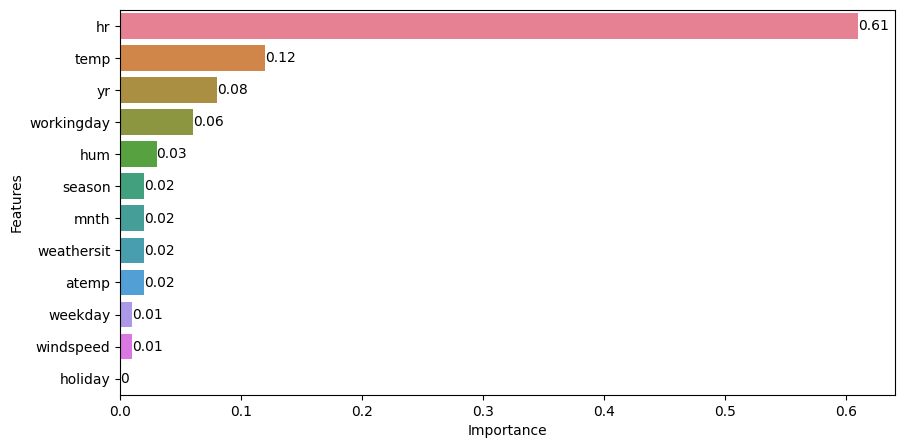

In [ ]:
# plotting graphical representation of feature importance
plt.figure(figsize=(10, 5))
plot_2 = sns.barplot(data=feature_importance, x = 'Importance', y = "Features", hue = 'Features')

for value in plot_2.containers :
  plot_2.bar_label(value)

plt.show()

##### **As per the Tunned Random Forest Regressor, Hours, temperature, Year, Workingday & Season this parameters are highly impacting to influence the Bike rental or Bike Sharing demand.**

# **Building Boosting Model's**

### **AdaBoost Regressor (simple)**

In [ ]:
# defining the model
simple_adaboost_regressor = AdaBoostRegressor(random_state = 1)

In [ ]:
# Passing the data into trained model
simple_adaboost_regressor.fit(X_train, y_train)

AdaBoostRegressor(random_state=1)

In [ ]:
# checking the model trained model performance on train data
simple_adaboost_model_evaluation_train = Model_performance_regression(simple_adaboost_regressor, X_train, y_train)
simple_adaboost_model_evaluation_train

,MAPE,MAE,MSE,RMSE,R2 Score,adj_r2
0,185.87734,80.99603,10908.09860,104.44184,0.66207,0.66173


In [ ]:
# checking the model trained model performance on test data
simple_adaboost_model_evaluation_test = Model_performance_regression(simple_adaboost_regressor, X_test, y_test)
simple_adaboost_model_evaluation_test

,MAPE,MAE,MSE,RMSE,R2 Score,adj_r2
0,196.40308,81.46836,11112.47582,105.41573,0.67632,0.67557


* Model genrallizing well but performance is poor.
* R2 score is very low & RMSE also.

### **AdaBoost Regressor (Tunned)**

In [ ]:
# defining the parameters
param_grid = {
    'n_estimators' : np.arange(10, 100, 10),
    'learning_rate' : [1, 0.1, 0.5, 0.01]
}

In [ ]:
# defining the score matrics
score = metrics.make_scorer(metrics.r2_score)

# defining the grid search cv
grid_search_cv_model = GridSearchCV(
    estimator= AdaBoostRegressor(random_state = 1),
    param_grid = param_grid,
    scoring = score,
    cv = 5,
    n_jobs = -1
)

In [ ]:
# fitting data into trained model
grid_search_cv_model.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=AdaBoostRegressor(random_state=1), n_jobs=-1,
             param_grid={'learning_rate': [1, 0.1, 0.5, 0.01],
                         'n_estimators': array([10, 20, 30, 40, 50, 60, 70, 80, 90])},
             scoring=make_scorer(r2_score, response_method='predict'))

In [ ]:
# best parameters
grid_search_cv_model.best_params_

{'learning_rate': 1, 'n_estimators': np.int64(30)}

In [ ]:
# best estimators
tunned_adaboost_regressor = grid_search_cv_model.best_estimator_
tunned_adaboost_regressor

AdaBoostRegressor(learning_rate=1, n_estimators=np.int64(30), random_state=1)

In [ ]:
# checking the model evaluation on train
tunned_adaboost_model_evaluation_train = Model_performance_regression(tunned_adaboost_regressor, X_train, y_train)
tunned_adaboost_model_evaluation_train

,MAPE,MAE,MSE,RMSE,R2 Score,adj_r2
0,195.18913,80.46881,10676.34062,103.32638,0.66925,0.66892


In [ ]:
# checking the model evaluation on test
tunned_adaboost_model_evaluation_test = Model_performance_regression(tunned_adaboost_regressor, X_test, y_test)
tunned_adaboost_model_evaluation_test

,MAPE,MAE,MSE,RMSE,R2 Score,adj_r2
0,207.46789,81.01517,10905.72055,104.43046,0.68234,0.68161


* Model Genralizing well, but performance is poor, on basis of R2 score & RMSE.
* not that much performance is imporoved after hyperparameter tunning.
* Not that much getting imporovment on R2 score after & Before hyperparameter tunning.

### **Feature Importance**

In [ ]:
feature_importance = pd.DataFrame({
    "Features" : X_train.columns,
    "Importance" : tunned_adaboost_regressor.feature_importances_.round(2)
}).sort_values(by = ['Importance'], ascending = False)

print(feature_importance)

      Features  Importance
3           hr     0.52000
1           yr     0.14000
9        atemp     0.08000
6   workingday     0.06000
10         hum     0.05000
0       season     0.05000
7   weathersit     0.05000
2         mnth     0.04000
8         temp     0.03000
5      weekday     0.00000
4      holiday     0.00000
11   windspeed     0.00000


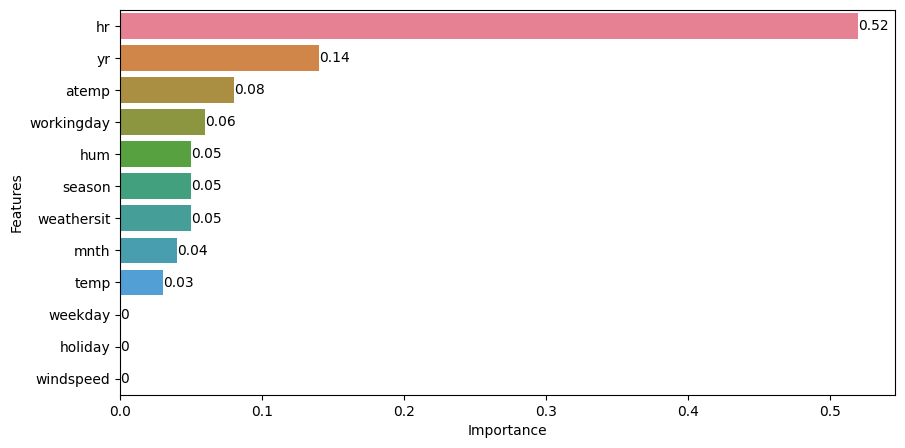

In [ ]:
# plotting the above summary in graph
plt.figure(figsize = (10, 5))
plot_3 = sns.barplot(data = feature_importance, x = "Importance", y = "Features", hue = "Features")

for values in plot_3.containers :
  plot_3.bar_label(values)

plt.show()


##### **As per the above graph, Hours, Year, Temperature feels like, Workingday, Humidity, season, weathersit, month, temperature are influencing the Bike-sharing demand or rental bike demands.**

### **Gradient Boosting Regressor (Simple)**

In [ ]:
# defining the simple gradient boosting model
simple_gbm = GradientBoostingRegressor(random_state = 1)

In [ ]:
# passing the data into trained model
simple_gbm.fit(X_train, y_train)

GradientBoostingRegressor(random_state=1)

In [ ]:
# checking the model performance on train data
simple_gbm_evaluation_train = Model_performance_regression(simple_gbm, X_train, y_train)
simple_gbm_evaluation_train

,MAPE,MAE,MSE,RMSE,R2 Score,adj_r2
0,92.15254,48.51804,5165.95666,71.87459,0.83996,0.83980


In [ ]:
# checking the model performance on test data
simple_gbm_evaluation_test = Model_performance_regression(simple_gbm, X_test, y_test)
simple_gbm_evaluation_test

,MAPE,MAE,MSE,RMSE,R2 Score,adj_r2
0,100.14979,49.69112,5501.67529,74.17328,0.83975,0.83938


* Model Genralizing well. with good R2 score around 0.83 on both train & test.
* No Overfitting or underfitting.
* Model is very stable.
* But MAPE on test is terrible, is indicating like prediction error are wrong by ~100% on average.

### **Gradient Boosting Regressor (Tunned)**

In [ ]:
# defining the parameters
param_grid = {
    'n_estimators' : np.arange(50, 200, 25),
    'subsample' : [0.7, 0.8, 0.9, 1],
    'max_features' : [0.7, 0.8, 0.9, 1],
    'max_depth' : [3, 5, 7, 10]
}

In [ ]:
# type of scoring tho used to compare to matrics
score = metrics.make_scorer(metrics.r2_score)

In [ ]:
# finding the best estimatores & best parameters
grid_search_cv = GridSearchCV(
  estimator = GradientBoostingRegressor(random_state =1),
  param_grid = param_grid,
  cv = 5,
  scoring = score,
  n_jobs = -1
)

In [ ]:
# passing the data into trained model
grid_search_cv.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=1),
             n_jobs=-1,
             param_grid={'max_depth': [3, 5, 7, 10],
                         'max_features': [0.7, 0.8, 0.9, 1],
                         'n_estimators': array([ 50,  75, 100, 125, 150, 175]),
                         'subsample': [0.7, 0.8, 0.9, 1]},
             scoring=make_scorer(r2_score, response_method='predict'))

In [198]:
# finding the best paramenters
best_param = grid_search_cv.best_params_
best_param

{'max_depth': 7,
 'max_features': 0.9,
 'n_estimators': np.int64(175),
 'subsample': 0.7}

In [199]:
# finding the best estimatres
tunned_gbm = grid_search_cv.best_estimator_
tunned_gbm

GradientBoostingRegressor(max_depth=7, max_features=0.9,
                          n_estimators=np.int64(175), random_state=1,
                          subsample=0.7)

In [200]:
# model performance checking on train data
tunned_gbm_evaluation_train = Model_performance_regression(tunned_gbm, X_train, y_train)
tunned_gbm_evaluation_train

,MAPE,MAE,MSE,RMSE,R2 Score,adj_r2
0,23.16897,14.72650,496.05751,22.27235,0.98463,0.98462


In [201]:
# model performance checking on test data
tunned_gbm_evaluation_test = Model_performance_regression(tunned_gbm, X_test, y_test)
tunned_gbm_evaluation_test

,MAPE,MAE,MSE,RMSE,R2 Score,adj_r2
0,36.01227,24.10188,1526.95428,39.07626,0.95552,0.95542


* After tunning the GradientBoosting model, our model performing well.
* Recall increased from 0.83 to 0.95, indicating model genralizing well.
* RSME decrased by 35%. which is good. MAPE is also decreased from 100 to 36.
* This tunned model prediction error around 39% only.

### **Feature Importance**

In [203]:
feature_imp = pd.DataFrame({
    "Features" : X_train.columns,
    "Importance" : tunned_gbm.feature_importances_.round(2)
}).sort_values(by = ['Importance'], ascending = False)

print(feature_imp)

      Features  Importance
3           hr     0.58000
8         temp     0.10000
6   workingday     0.08000
1           yr     0.08000
9        atemp     0.05000
0       season     0.02000
10         hum     0.02000
5      weekday     0.02000
7   weathersit     0.02000
2         mnth     0.01000
11   windspeed     0.01000
4      holiday     0.00000


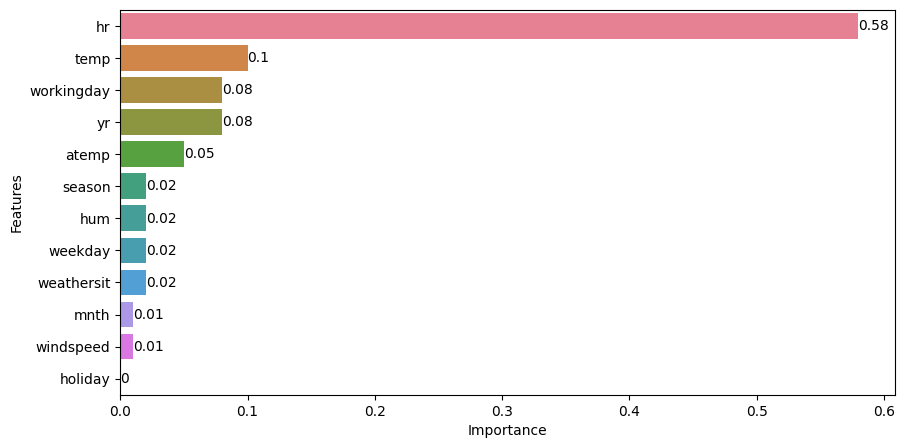

In [205]:
# graphical representation of Feature importances
plt.figure(figsize = (10, 5))

plot_4 = sns.barplot(data = feature_imp, x = 'Importance', y = 'Features', hue = 'Features')

for values in plot_4.containers:
  plot_4.bar_label(values)

plt.show()

##### **IN tunned Gradient boosting model, Hours, Temperature, Working days, year, temperature (feels like), season, humidity, weekday, weathersit are highly influencing the Bike-sharing or rental bike demand's.**

### **XGB Regressor (Simple)**

In [208]:
# defining the XGB model
simple_xgb = XGBRegressor(random_state = 1, verbosity = 0)
simple_xgb

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [209]:
# passing the data into trained model
simple_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [210]:
# checking the trained XGB model performance on train data
simple_xgb_evaluation_train = Model_performance_regression(simple_xgb, X_train, y_train)
simple_xgb_evaluation_train

,MAPE,MAE,MSE,RMSE,R2 Score,adj_r2
0,29.89749,17.48936,722.10034,26.87192,0.97763,0.97761


In [211]:
# checking the trained XGB model performance on train data
simple_xgb_evaluation_test = Model_performance_regression(simple_xgb, X_test, y_test)
simple_xgb_evaluation_test

,MAPE,MAE,MSE,RMSE,R2 Score,adj_r2
0,44.23373,25.81622,1679.06787,40.97643,0.95109,0.95098


* Model is genarlizing well, R2 score is around 0.95 on test & 0.97 on train not that much difference.
* RMSE is increased from 26 to 40. seems like model prediction error on unseen data around 40%. which is not that much good. but as compaire to tunned gbm model its giving good r2 score & RSME.

### **XGB Regressor (Tunned)**

In [212]:
# defining the parameter for gridsearch cv XGBM
param_grid = {
    'n_estimators' : [75, 100, 125, 150],
    'subsample' : [0.7, 0.8, 0.9, 1],
    'gamma' : [0, 1, 3, 5],
    'colsample_bytree' : [0.7, 0.8, 0.9, 1],
    'colsample_bylevel' : [0.7, 0.8, 0.9, 1]
}

In [213]:
# scoring parameter
scoring = metrics.make_scorer(metrics.r2_score)

In [214]:
# defining the grid search cv with XGBM
gird_search_cv = GridSearchCV(
    estimator = XGBRegressor(random_state = 1, verbosity = 0),
    param_grid = param_grid,
    cv = 5,
    n_jobs = -1
)

In [215]:
# fittng data into trained model
gird_search_cv.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bylevel': [0.7, 0.8, 0.9, 1],
                         'colsample_bytree': [0.7, 0.8, 0.9, 1],
                         'gamma': [0, 1, 3, 5],
                         'n_estimators': [75, 100, 125, 150],
                         'subsample': [0.7, 0.8, 0.9, 1]})

In [216]:
# best parameters
gird_search_cv.best_params_

{'colsample_bylevel': 0.8,
 'colsample_bytree': 1,
 'gamma': 0,
 'n_estimators': 150,
 'subsample': 1}

In [217]:
# best estimatoers
tunned_XGB = gird_search_cv.best_estimator_
tunned_XGB

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=0.8, colsample_bynode=None, colsample_bytree=1,
             device=None, early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=0, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=150, n_jobs=None,
             num_parallel_tree=None, ...)

In [218]:
# fitting the data into tunned model
tunned_XGB.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=0.8, colsample_bynode=None, colsample_bytree=1,
             device=None, early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=0, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=150, n_jobs=None,
             num_parallel_tree=None, ...)

In [219]:
# checking the model performance on train data
tunned_xgb_evaluation_train = Model_performance_regression(tunned_XGB, X_train, y_train)
tunned_xgb_evaluation_train

,MAPE,MAE,MSE,RMSE,R2 Score,adj_r2
0,28.28418,15.91915,593.50055,24.36187,0.98161,0.98160


In [220]:
# checking the model performance on test data
tunned_xgb_evaluation_test = Model_performance_regression(tunned_XGB, X_test, y_test)
tunned_xgb_evaluation_test

,MAPE,MAE,MSE,RMSE,R2 Score,adj_r2
0,42.67114,25.79606,1671.85083,40.88827,0.95130,0.95119


* After tunning, model giving same performance. R2 score is around 0.95 & RMSE isaround 40.

### **Feature Importance**

In [222]:
feature_importance = pd.DataFrame({
    "Features" : X_train.columns,
    "Importance" : tunned_XGB.feature_importances_.round(2)
}).sort_values(by = ['Importance'], ascending = False)

print(feature_importance)

      Features  Importance
6   workingday     0.27000
3           hr     0.23000
1           yr     0.18000
9        atemp     0.11000
0       season     0.06000
7   weathersit     0.04000
8         temp     0.03000
5      weekday     0.03000
10         hum     0.02000
2         mnth     0.01000
4      holiday     0.01000
11   windspeed     0.00000


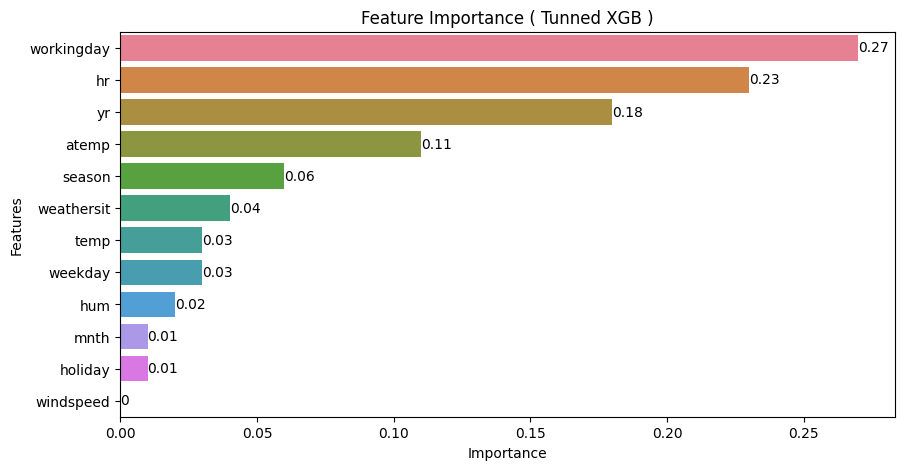

In [224]:
# plotting the feature importance inform of graph

plt.figure(figsize = (10, 5))
plt.title("Feature Importance ( Tunned XGB )")
plot_5 = sns.barplot( data = feature_importance, x = 'Importance', y = 'Features', hue = 'Features' )

for values in plot_5.containers:
  plot_5.bar_label(values)

plt.show()

##### **In this tunned XGBM, Working day, hour's, year, temperature (feels like) are most important parameters to influencing Bike-Sharing or Bike-rentals demands.**

### **Stacking Model**

**Now, let's build a stacking model with the tuned models - decision tree, random forest, and gradient boosting, then use XGBoost to get the final prediction.**

In [225]:
estimators = [('Decision tree', tunned_dtree_regressor), ('Random Forest', tunned_random_forest), ('Gradient Boosting', tunned_XGB)]

final_estimator = XGBRegressor(random_state=1)

In [226]:
stacking_estimator = StackingRegressor(
  estimators = estimators,
  final_estimator = final_estimator,
  cv = 5
)

stacking_estimator.fit(X_train, y_train)

StackingRegressor(cv=5,
                  estimators=[('Decision tree',
                               DecisionTreeRegressor(max_depth=np.int64(14),
                                                     min_impurity_decrease=0.1,
                                                     min_samples_leaf=5,
                                                     random_state=1)),
                              ('Random Forest',
                               RandomForestRegressor(max_features=None,
                                                     n_estimators=np.int64(110),
                                                     random_state=1)),
                              ('Gradient Boosting',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylev...
                                               feature_weights=None, gamma=None,
                                               grow_policy=None,
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=None, max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None,
                                               max_depth=None, max_leaves=None,
                                               min_child_weight=None,
                                               missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=None, n_jobs=None,
                                               num_parallel_tree=None, ...))

In [227]:
# model performance on train data
stacking_model_evauation_train = Model_performance_regression(stacking_estimator, X_train, y_train)
stacking_model_evauation_train

,MAPE,MAE,MSE,RMSE,R2 Score,adj_r2
0,16.05524,13.59708,506.88553,22.51412,0.98430,0.98428


In [229]:
# model performance on test data
stacking_model_evauation_test = Model_performance_regression(stacking_estimator, X_test, y_test)
stacking_model_evauation_test

,MAPE,MAE,MSE,RMSE,R2 Score,adj_r2
0,30.65528,25.48841,1821.11890,42.67457,0.94696,0.94683


### **Comparing all models**

In [232]:
model_performance_test = pd.concat([
    simple_dt_model_evaluation_test.T,
    tunned_dt_model_evaluation_test.T,
    simple_randomF_model_evaluation_test.T,
    tunned_randomF_model_evaluation_test.T,
    simple_adaboost_model_evaluation_test.T,
    tunned_adaboost_model_evaluation_test.T,
    simple_gbm_evaluation_test.T,
    tunned_gbm_evaluation_test.T,
    simple_xgb_evaluation_test.T,
    tunned_xgb_evaluation_test.T,
    stacking_model_evauation_test.T
], axis = 1)

model_performance_test.columns=[
    "Simple DT",
    "Tunned DT",
    "Simple Random Forest",
    "Tunned Random Forest",
    "Simple AdaBoost",
    "Tunned AdaBoost",
    "Simple GBM",
    "Tunned GBM",
    "Simple XGB",
    "Tunned XGB",
    "Stacking Classifier"
]

print("Test Performance Comparison : ")
model_performance_test

Test Performance Comparison : 


,Simple DT,Tunned DT,Simple Random Forest,Tunned Random Forest,Simple AdaBoost,Tunned AdaBoost,Simple GBM,Tunned GBM,Simple XGB,Tunned XGB,Stacking Classifier
MAPE,38.03325,38.35640,32.74863,32.75475,196.40308,207.46789,100.14979,36.01227,44.23373,42.67114,30.65528
MAE,35.10779,31.84136,26.19237,26.20472,81.46836,81.01517,49.69112,24.10188,25.81622,25.79606,25.48841
MSE,3700.02532,3021.69622,1985.78521,1987.25566,11112.47582,10905.72055,5501.67529,1526.95428,1679.06787,1671.85083,1821.11890
RMSE,60.82783,54.96996,44.56215,44.57865,105.41573,104.43046,74.17328,39.07626,40.97643,40.88827,42.67457
R2 Score,0.89223,0.91199,0.94216,0.94212,0.67632,0.68234,0.83975,0.95552,0.95109,0.95130,0.94696
adj_r2,0.89198,0.91178,0.94203,0.94198,0.67557,0.68161,0.83938,0.95542,0.95098,0.95119,0.94683


* From above summary, we finalize the Tunned GBM model. Giving excellent R2 score & less MAE with MAPE percentage (Prediction error) comparing with other's.
* Also RMSE is less as compaire to other model's.

# **Conclusions and Business Recommendations**

* We can use this predictive model for any season and environmental parameters (which we know in advance) and can predict the count of the bikes to be rented. The ability to predict the number of hourly users can allow the entities (businesses/governments) that oversee these systems to manage them more efficiently and cost-effectively.
* More bikes can be made available for the fall and winter seasons as the number of bikes rented is high in these seasons.
* As the number of bikes rented is high for day timings compared to night timings, similarly, fall and winter seasons have more surges compared to other seasons. We can choose differential prices of bikes accordingly.
* As most of the rentals are for commuting to workplaces and colleges daily, company can launch more stations near busy workplaces or schools/colleges to reach out to their main customers.
* Number of bikes rented is heavily dependent on the weather. So, we should adjust the number of available bikes in an area based on the weather forecast.
* Maintenance activities for bikes can be done at night due to low usage of bikes during the nighttime.
* Company can provide offers or coupons like a monthly subscription to compensate for the low count on holidays or weekends.